# 518880 recovery drift 细化展示

这个 notebook 只读取已经生成好的 CSV：

- `data/spread2_recovery_drift/`
- `data/spread2_close_path/`

不直接加载 snapshot，目标是把 `rollback_close` 和 `advance_close` 在回正之后的 `mid_price drift` 拆得更细。

这次重点看四件事：

- 更长的固定时间窗 `1s -> 60s`
- 更长的 `mid_price` 非零移动次数 `1 -> 10`
- `close` 前后更长的事件窗口
- 这些差异到底是均值现象，还是分布层面也一致


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / 'data').exists():
    if (BASE_DIR.parent / 'data').exists():
        BASE_DIR = BASE_DIR.parent
    elif (BASE_DIR / '518880' / 'data').exists():
        BASE_DIR = BASE_DIR / '518880'

DRIFT_DIR = BASE_DIR / 'data' / 'spread2_recovery_drift'
CLOSE_DIR = BASE_DIR / 'data' / 'spread2_close_path'


def read_csv(folder: Path, name: str) -> pd.DataFrame:
    path = folder / f'{name}.csv'
    if not path.exists():
        raise FileNotFoundError(f'missing csv: {path}')
    return pd.read_csv(path)


def pivot_metric(df: pd.DataFrame, metric: str, index_cols: list[str]):
    return df.pivot_table(index=index_cols, columns='resolution_path', values=metric)


## 1. 如何刷新数据

如果要重新生成研究结果，在 notebook 同目录执行：

```bash
/opt/conda/bin/python3.13 ../code/spread2_close_path.py
/opt/conda/bin/python3.13 ../code/spread2_recovery_drift.py
```


In [2]:
overview = read_csv(DRIFT_DIR, 'overview')
summary = read_csv(DRIFT_DIR, 'drift_summary')
samples = read_csv(DRIFT_DIR, 'drift_samples')
event_summary = read_csv(DRIFT_DIR, 'event_window_summary')
event_samples = read_csv(DRIFT_DIR, 'event_window_samples')
episodes = read_csv(CLOSE_DIR, 'episode_samples')

episodes = episodes[episodes['resolution_path'].isin(['advance_close', 'rollback_close'])].copy()
detail = samples.merge(
    episodes[['trade_ymd', 'entry_time', 'close_time', 'entry_mechanism', 'duration_seconds']],
    on=['trade_ymd', 'entry_time', 'close_time'],
    how='left',
)
event_detail = event_samples.merge(
    episodes[['trade_ymd', 'entry_time', 'close_time', 'entry_mechanism', 'duration_seconds']],
    on=['trade_ymd', 'entry_time', 'close_time'],
    how='left',
)

display(overview)

row = overview.iloc[0]
text = f'''
### 样本概览

- 交易日数: `{int(row['trade_days'])}`
- 常规时段快照数: `{int(row['panel_rows']):,}`
- episode 数: `{int(row['episodes_total']):,}`
- `advance_close` 样本数: `{int(row['advance_close_samples']):,}`
- `rollback_close` 样本数: `{int(row['rollback_close_samples']):,}`
- 事件窗口相对秒范围: `[{int(event_summary['relative_second'].min())}, {int(event_summary['relative_second'].max())}]`
'''
display(Markdown(text))


,trade_days,panel_rows,episodes_total,advance_close_samples,rollback_close_samples
0,49,705331,29530,15210,14320



### 样本概览

- 交易日数: `49`
- 常规时段快照数: `705,331`
- episode 数: `29,530`
- `advance_close` 样本数: `15,210`
- `rollback_close` 样本数: `14,320`
- 事件窗口相对秒范围: `[-10, 30]`


## 2. 全部 horizon 摊开看

这里的 `signed_post_close_drift_tick` 统一定义为：

- 沿扩价原方向为正
- 反向为负
- 从 `close` 秒之后开始累计，不把回正当秒混进去


In [3]:
display(summary)

mean_pivot = pivot_metric(summary, 'mean_signed_drift_tick', ['horizon_type', 'horizon_value'])
mean_pivot['rollback_minus_advance'] = mean_pivot['rollback_close'] - mean_pivot['advance_close']
display(mean_pivot.reset_index())


,horizon_type,horizon_value,resolution_path,samples,trade_days,avg_elapsed_seconds,median_elapsed_seconds,mean_drift_tick,median_drift_tick,mean_signed_drift_tick,median_signed_drift_tick,continue_ratio,reverse_ratio,flat_ratio,rollback_minus_advance
0,mid_moves,1,advance_close,15206,49,3.8853,2.0000,-0.0185,-0.5000,-0.1901,-0.5000,0.3889,0.6111,0.0000,0.4311
1,mid_moves,1,rollback_close,14319,49,3.4671,2.0000,-0.0227,-0.5000,0.2411,0.5000,0.6346,0.3654,0.0000,0.4311
2,mid_moves,2,advance_close,15201,49,7.3976,4.0000,0.0053,0.0000,-0.0569,-0.0000,0.2771,0.3391,0.3838,0.2161
3,mid_moves,2,rollback_close,14316,49,6.8330,4.0000,-0.0197,0.0000,0.1592,0.0000,0.3624,0.2492,0.3884,0.2161
4,mid_moves,3,advance_close,15197,49,11.0520,6.0000,-0.0071,0.0000,-0.0420,0.0000,0.4103,0.4793,0.1104,0.2370
5,mid_moves,3,rollback_close,14314,49,10.3353,6.0000,-0.0134,0.0000,0.1949,0.5000,0.5138,0.3768,0.1095,0.2370
6,mid_moves,4,advance_close,15195,49,14.6974,9.0000,-0.0173,0.0000,-0.0142,0.0000,0.3628,0.3995,0.2376,0.1992
7,mid_moves,4,rollback_close,14310,49,13.8888,9.0000,-0.0305,0.0000,0.1850,0.0000,0.4289,0.3275,0.2437,0.1992
8,mid_moves,5,advance_close,15192,49,18.3256,12.0000,-0.0190,0.0000,-0.0044,0.0000,0.4203,0.4593,0.1204,0.1797
9,mid_moves,5,rollback_close,14305,49,17.5058,11.0000,-0.0347,0.0000,0.1753,-0.0000,0.4914,0.3870,0.1216,0.1797


resolution_path,horizon_type,horizon_value,advance_close,rollback_close,rollback_minus_advance
0,mid_moves,1,-0.1901,0.2411,0.4311
1,mid_moves,2,-0.0569,0.1592,0.2161
2,mid_moves,3,-0.0420,0.1949,0.2370
3,mid_moves,4,-0.0142,0.1850,0.1992
4,mid_moves,5,-0.0044,0.1753,0.1797
5,mid_moves,8,0.0492,0.1666,0.1174
6,mid_moves,10,0.0566,0.1662,0.1095
7,time_seconds,1,-0.1200,0.1446,0.2647
8,time_seconds,2,-0.1124,0.1585,0.2709
9,time_seconds,3,-0.0986,0.1811,0.2798


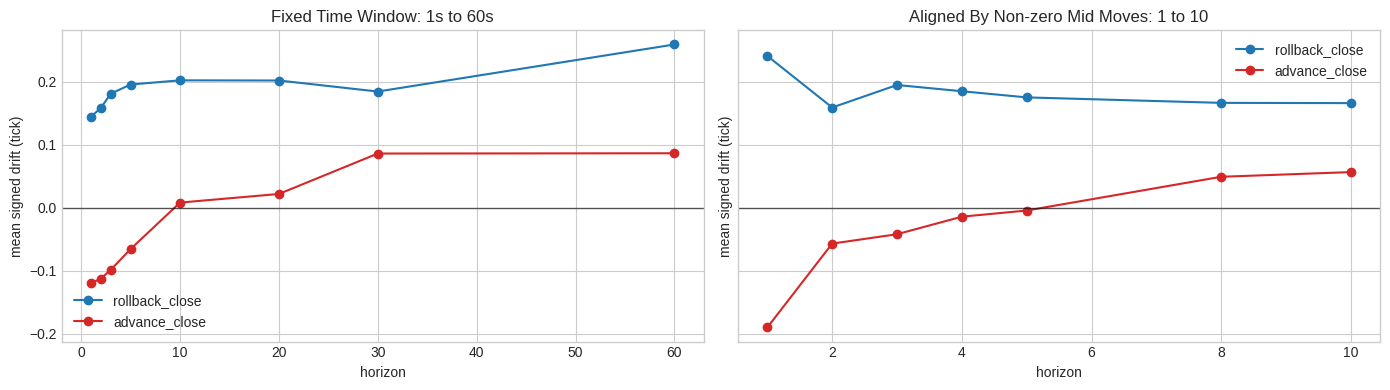

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, horizon_type, title in zip(
    axes,
    ['time_seconds', 'mid_moves'],
    ['Fixed Time Window: 1s to 60s', 'Aligned By Non-zero Mid Moves: 1 to 10'],
):
    sub = summary[summary['horizon_type'] == horizon_type].copy()
    for path_name, color in [('rollback_close', '#1f77b4'), ('advance_close', '#d62728')]:
        line = sub[sub['resolution_path'] == path_name]
        ax.plot(line['horizon_value'], line['mean_signed_drift_tick'], marker='o', label=path_name, color=color)
    ax.axhline(0.0, color='black', linewidth=1, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('horizon')
    ax.set_ylabel('mean signed drift (tick)')
    ax.legend()
plt.tight_layout()


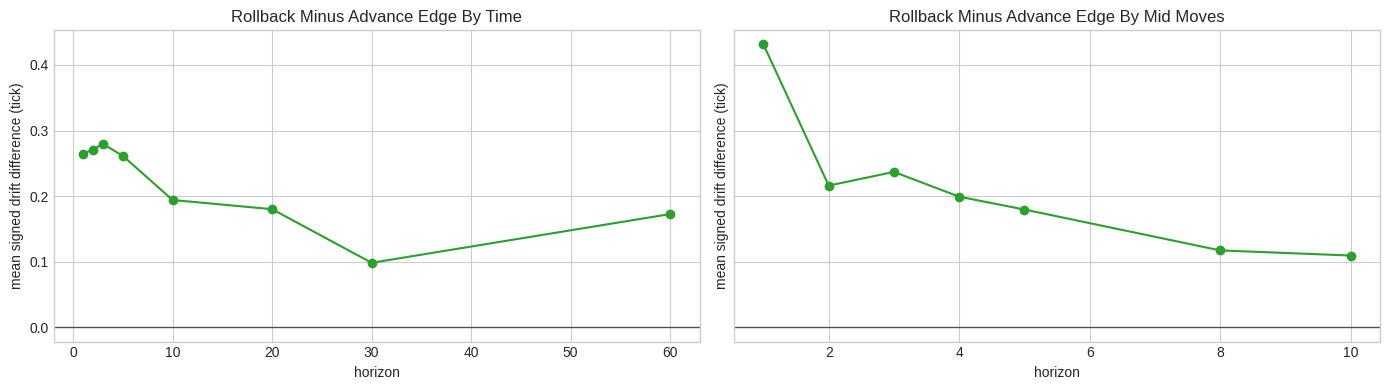

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, horizon_type, title in zip(
    axes,
    ['time_seconds', 'mid_moves'],
    ['Rollback Minus Advance Edge By Time', 'Rollback Minus Advance Edge By Mid Moves'],
):
    sub = mean_pivot.reset_index()
    sub = sub[sub['horizon_type'] == horizon_type]
    ax.plot(sub['horizon_value'], sub['rollback_minus_advance'], marker='o', color='#2ca02c')
    ax.axhline(0.0, color='black', linewidth=1, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('horizon')
    ax.set_ylabel('mean signed drift difference (tick)')
plt.tight_layout()


## 3. 只看均值不够，再看方向比例和热力图

下面把 `continue / reverse / flat` 比例也展开。这样可以区分：

- 是均值少数极端样本拉出来的
- 还是大多数样本方向本身就在分化


In [6]:
for metric in ['continue_ratio', 'reverse_ratio', 'flat_ratio']:
    table = pivot_metric(summary, metric, ['horizon_type', 'horizon_value'])
    display(Markdown(f'### {metric}'))
    display(table.reset_index())


### continue_ratio

resolution_path,horizon_type,horizon_value,advance_close,rollback_close
0,mid_moves,1,0.3889,0.6346
1,mid_moves,2,0.2771,0.3624
2,mid_moves,3,0.4103,0.5138
3,mid_moves,4,0.3628,0.4289
4,mid_moves,5,0.4203,0.4914
5,mid_moves,8,0.4242,0.4628
6,mid_moves,10,0.4374,0.4704
7,time_seconds,1,0.1527,0.3129
8,time_seconds,2,0.2071,0.3598
9,time_seconds,3,0.2356,0.3991


### reverse_ratio

resolution_path,horizon_type,horizon_value,advance_close,rollback_close
0,mid_moves,1,0.6111,0.3654
1,mid_moves,2,0.3391,0.2492
2,mid_moves,3,0.4793,0.3768
3,mid_moves,4,0.3995,0.3275
4,mid_moves,5,0.4593,0.3870
5,mid_moves,8,0.4323,0.3959
6,mid_moves,10,0.4432,0.4116
7,time_seconds,1,0.2917,0.1531
8,time_seconds,2,0.3386,0.1996
9,time_seconds,3,0.3584,0.2282


### flat_ratio

resolution_path,horizon_type,horizon_value,advance_close,rollback_close
0,mid_moves,1,0.0000,0.0000
1,mid_moves,2,0.3838,0.3884
2,mid_moves,3,0.1104,0.1095
3,mid_moves,4,0.2376,0.2437
4,mid_moves,5,0.1204,0.1216
5,mid_moves,8,0.1435,0.1413
6,mid_moves,10,0.1195,0.1180
7,time_seconds,1,0.5556,0.5340
8,time_seconds,2,0.4543,0.4406
9,time_seconds,3,0.4060,0.3727


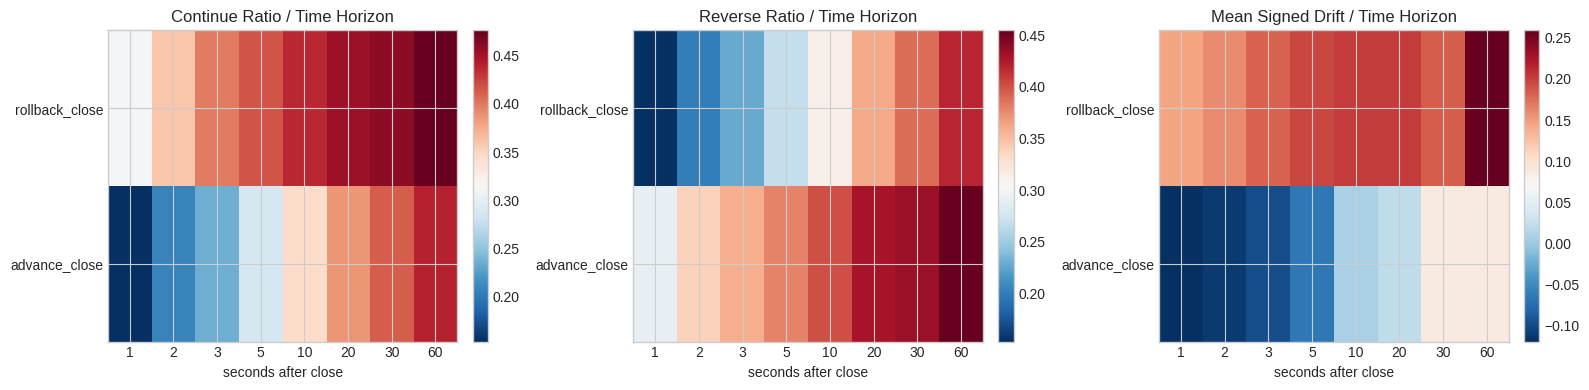

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, title in zip(
    axes,
    ['continue_ratio', 'reverse_ratio', 'mean_signed_drift_tick'],
    ['Continue Ratio', 'Reverse Ratio', 'Mean Signed Drift'],
):
    sub = summary[summary['horizon_type'] == 'time_seconds'].pivot(index='horizon_value', columns='resolution_path', values=metric)
    mat = sub[['rollback_close', 'advance_close']].T
    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r')
    ax.set_title(title + ' / Time Horizon')
    ax.set_xticks(range(len(sub.index)))
    ax.set_xticklabels(sub.index)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['rollback_close', 'advance_close'])
    ax.set_xlabel('seconds after close')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()


## 4. 分布层面也看一下，不只看均值

这里选两个较长 horizon：

- 固定 `30s`
- 到第 `10` 次非零 `mid move`

如果分布层面仍然分开，说明差异不是偶然的均值残差。


/tmp/ipykernel_206671/1551625813.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row_idx, 0].boxplot(arrays, labels=labels, showfliers=False)
/tmp/ipykernel_206671/1551625813.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row_idx, 0].boxplot(arrays, labels=labels, showfliers=False)


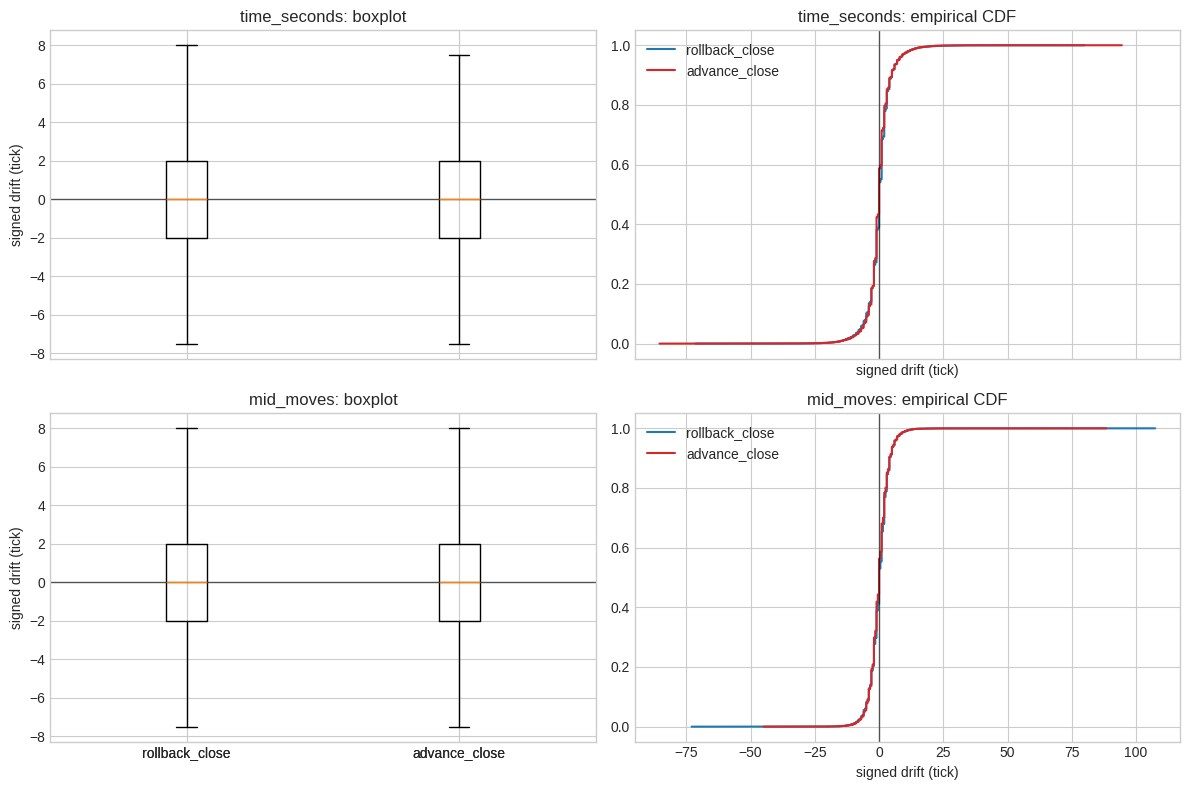

In [8]:
focus = detail[
    ((detail['horizon_type'] == 'time_seconds') & (detail['horizon_value'] == 30)) |
    ((detail['horizon_type'] == 'mid_moves') & (detail['horizon_value'] == 10))
].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col')
for row_idx, horizon_type in enumerate(['time_seconds', 'mid_moves']):
    sub = focus[focus['horizon_type'] == horizon_type].copy()
    labels = []
    arrays = []
    for path_name in ['rollback_close', 'advance_close']:
        arr = sub.loc[sub['resolution_path'] == path_name, 'signed_post_close_drift_tick'].dropna().values
        labels.append(path_name)
        arrays.append(arr)
    axes[row_idx, 0].boxplot(arrays, labels=labels, showfliers=False)
    axes[row_idx, 0].axhline(0.0, color='black', linewidth=1, alpha=0.6)
    axes[row_idx, 0].set_title(f'{horizon_type}: boxplot')
    axes[row_idx, 0].set_ylabel('signed drift (tick)')

    for path_name, color in [('rollback_close', '#1f77b4'), ('advance_close', '#d62728')]:
        arr = np.sort(sub.loc[sub['resolution_path'] == path_name, 'signed_post_close_drift_tick'].dropna().values)
        if len(arr) == 0:
            continue
        y = np.linspace(0, 1, len(arr), endpoint=False)
        axes[row_idx, 1].plot(arr, y, label=path_name, color=color)
    axes[row_idx, 1].axvline(0.0, color='black', linewidth=1, alpha=0.6)
    axes[row_idx, 1].set_title(f'{horizon_type}: empirical CDF')
    axes[row_idx, 1].set_xlabel('signed drift (tick)')
    axes[row_idx, 1].legend()
plt.tight_layout()


## 5. `mid move` 口径还有一个额外问题：要等多久

按第 `N` 次非零 `mid move` 对齐时，不同恢复类型可能需要不同物理时间。
如果其中一种总是更慢，就要小心解释。


,horizon_value,resolution_path,samples,mean_elapsed_seconds,median_elapsed_seconds,q75_elapsed_seconds
0,1,advance_close,15206,3.8853,2.0000,4.0000
1,1,rollback_close,14319,3.4671,2.0000,3.0000
2,2,advance_close,15201,7.3976,4.0000,8.0000
3,2,rollback_close,14316,6.8330,4.0000,7.0000
4,3,advance_close,15197,11.0520,6.0000,12.0000
5,3,rollback_close,14314,10.3353,6.0000,11.0000
6,4,advance_close,15195,14.6974,9.0000,16.0000
7,4,rollback_close,14310,13.8888,9.0000,16.0000
8,5,advance_close,15192,18.3256,12.0000,21.0000
9,5,rollback_close,14305,17.5058,11.0000,20.0000


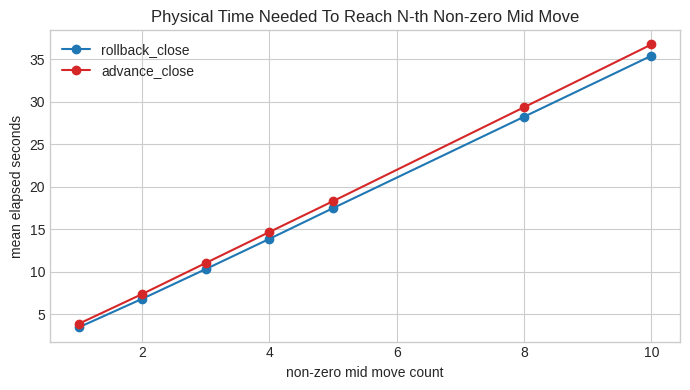

In [9]:
elapsed = (
    detail[detail['horizon_type'] == 'mid_moves']
    .groupby(['horizon_value', 'resolution_path'], observed=False)
    .agg(
        samples=('elapsed_seconds', 'size'),
        mean_elapsed_seconds=('elapsed_seconds', 'mean'),
        median_elapsed_seconds=('elapsed_seconds', 'median'),
        q75_elapsed_seconds=('elapsed_seconds', lambda x: x.quantile(0.75)),
    )
    .reset_index()
)
display(elapsed)

fig, ax = plt.subplots(figsize=(7, 4))
for path_name, color in [('rollback_close', '#1f77b4'), ('advance_close', '#d62728')]:
    sub = elapsed[elapsed['resolution_path'] == path_name]
    ax.plot(sub['horizon_value'], sub['mean_elapsed_seconds'], marker='o', label=path_name, color=color)
ax.set_title('Physical Time Needed To Reach N-th Non-zero Mid Move')
ax.set_xlabel('non-zero mid move count')
ax.set_ylabel('mean elapsed seconds')
ax.legend()
plt.tight_layout()


## 6. 更长事件窗口：`close` 前后路径到底长什么样

这里不再只看几个 horizon 点，而是直接看 `close` 前后 `[-10s, +30s]` 的平均路径。

要注意：

- `relative_second = 0` 是回正当秒
- `signed_mid_drift_from_close_tick` 在 `0` 时必然是 `0`
- 真正要看的是 `0` 之后路径如何继续展开


In [10]:
display(event_summary.head(20))

event_pivot = event_summary.pivot(index='relative_second', columns='resolution_path', values='mean_signed_mid_drift_tick')
event_pivot['rollback_minus_advance'] = event_pivot['rollback_close'] - event_pivot['advance_close']
display(event_pivot.reset_index().head(20))


,resolution_path,relative_second,samples,spread_ticks_mean,mid_move_half_tick_mean,mean_signed_mid_drift_tick,median_signed_mid_drift_tick,l1_imbalance_mean,l1_depth_mean,active_turnover_mean,nonzero_mid_move_ratio
0,advance_close,-10,15198,1.1698,-0.0182,-1.3494,-1.0000,-0.0043,"294,534.6205","750,852.4729",0.4091
1,advance_close,-9,15199,1.1674,-0.0289,-1.3464,-1.0000,-0.0070,"289,837.8478","777,075.4540",0.4173
2,advance_close,-8,15200,1.1758,-0.0122,-1.3322,-1.0000,-0.0066,"292,344.3859","780,096.2717",0.4189
3,advance_close,-7,15201,1.1722,-0.0167,-1.3220,-1.0000,-0.0139,"289,480.1521","782,982.7422",0.4276
4,advance_close,-6,15203,1.1806,0.0068,-1.3125,-1.0000,-0.0150,"284,579.2222","843,573.4959",0.4327
5,advance_close,-5,15205,1.1753,-0.0189,-1.3034,-1.0000,-0.0018,"279,014.3189","819,535.8324",0.4520
6,advance_close,-4,15207,1.1901,-0.0170,-1.2927,-1.0000,0.0033,"278,213.9933","804,363.7231",0.4625
7,advance_close,-3,15210,1.1998,0.0330,-1.2856,-1.0000,-0.0070,"275,517.5669","850,300.3780",0.4787
8,advance_close,-2,15210,1.2415,-0.0200,-1.2524,-1.0000,-0.0103,"281,644.1388","874,908.4698",0.5314
9,advance_close,-1,15210,2.0000,0.0014,-0.7133,-0.5000,0.0043,"402,700.7321","1,049,869.3816",0.8070


resolution_path,relative_second,advance_close,rollback_close,rollback_minus_advance
0,-10,-1.3494,0.2432,1.5926
1,-9,-1.3464,0.2387,1.5852
2,-8,-1.3322,0.2325,1.5647
3,-7,-1.3220,0.2250,1.5470
4,-6,-1.3125,0.2241,1.5366
5,-5,-1.3034,0.2093,1.5127
6,-4,-1.2927,0.1960,1.4886
7,-3,-1.2856,0.1794,1.4650
8,-2,-1.2524,0.1971,1.4495
9,-1,-0.7133,0.7089,1.4221


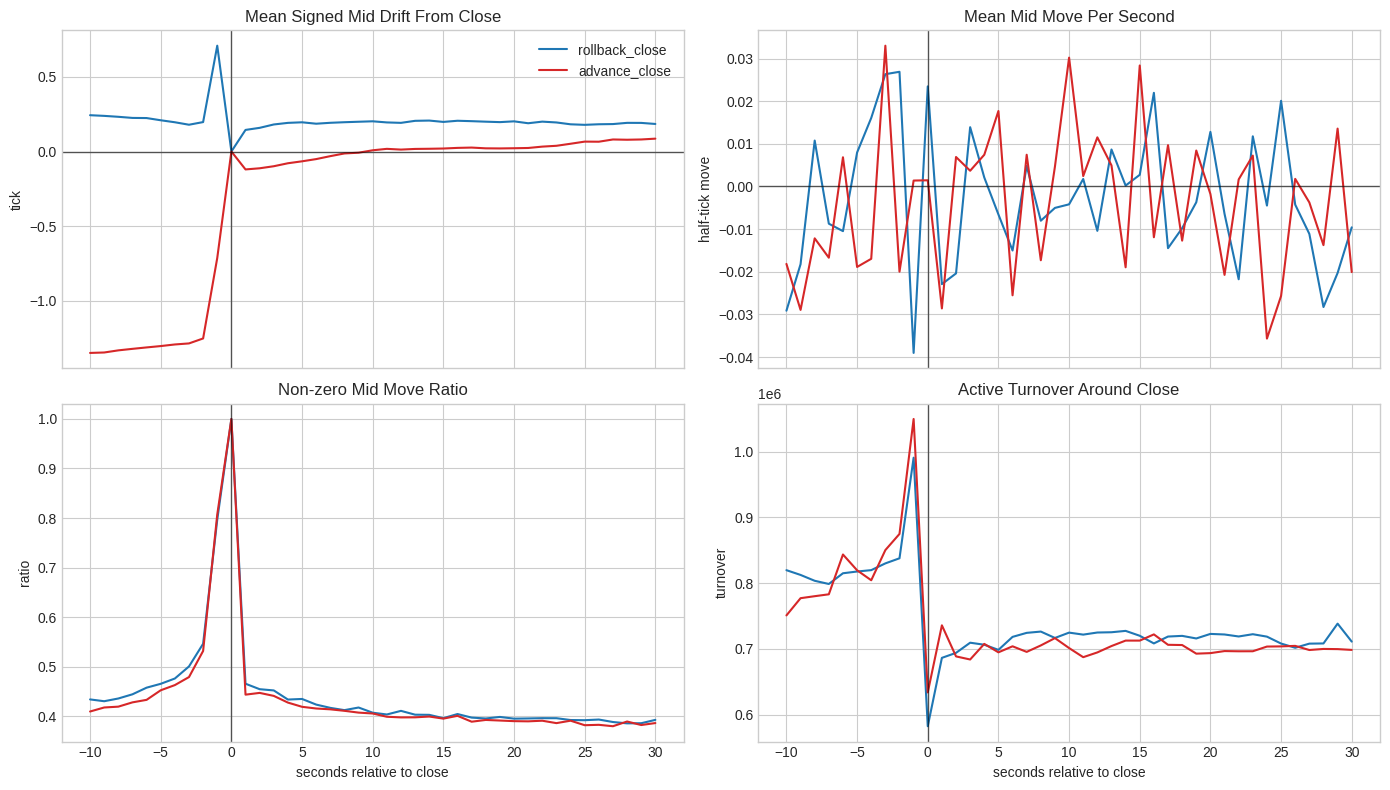

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

path_colors = {'rollback_close': '#1f77b4', 'advance_close': '#d62728'}
for path_name, color in path_colors.items():
    sub = event_summary[event_summary['resolution_path'] == path_name]
    axes[0, 0].plot(sub['relative_second'], sub['mean_signed_mid_drift_tick'], label=path_name, color=color)
    axes[0, 1].plot(sub['relative_second'], sub['mid_move_half_tick_mean'], label=path_name, color=color)
    axes[1, 0].plot(sub['relative_second'], sub['nonzero_mid_move_ratio'], label=path_name, color=color)
    axes[1, 1].plot(sub['relative_second'], sub['active_turnover_mean'], label=path_name, color=color)

axes[0, 0].axvline(0.0, color='black', linewidth=1, alpha=0.6)
axes[0, 0].axhline(0.0, color='black', linewidth=1, alpha=0.6)
axes[0, 0].set_title('Mean Signed Mid Drift From Close')
axes[0, 0].set_ylabel('tick')
axes[0, 0].legend()

axes[0, 1].axvline(0.0, color='black', linewidth=1, alpha=0.6)
axes[0, 1].axhline(0.0, color='black', linewidth=1, alpha=0.6)
axes[0, 1].set_title('Mean Mid Move Per Second')
axes[0, 1].set_ylabel('half-tick move')

axes[1, 0].axvline(0.0, color='black', linewidth=1, alpha=0.6)
axes[1, 0].set_title('Non-zero Mid Move Ratio')
axes[1, 0].set_ylabel('ratio')
axes[1, 0].set_xlabel('seconds relative to close')

axes[1, 1].axvline(0.0, color='black', linewidth=1, alpha=0.6)
axes[1, 1].set_title('Active Turnover Around Close')
axes[1, 1].set_ylabel('turnover')
axes[1, 1].set_xlabel('seconds relative to close')

plt.tight_layout()


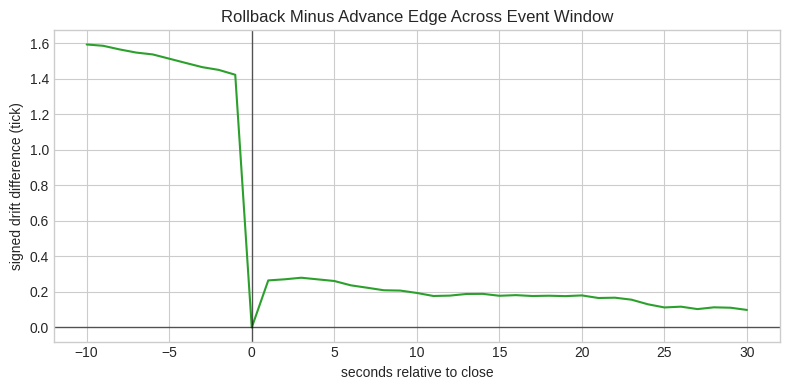

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(event_pivot.index, event_pivot['rollback_minus_advance'], color='#2ca02c')
ax.axvline(0.0, color='black', linewidth=1, alpha=0.6)
ax.axhline(0.0, color='black', linewidth=1, alpha=0.6)
ax.set_title('Rollback Minus Advance Edge Across Event Window')
ax.set_xlabel('seconds relative to close')
ax.set_ylabel('signed drift difference (tick)')
plt.tight_layout()


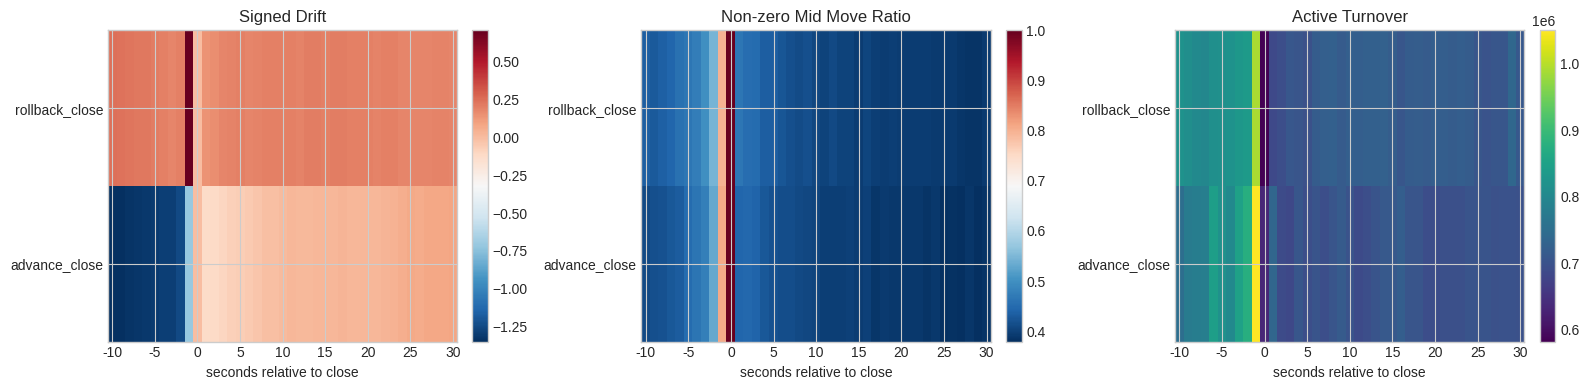

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
for ax, metric, title in zip(
    axes,
    ['mean_signed_mid_drift_tick', 'nonzero_mid_move_ratio', 'active_turnover_mean'],
    ['Signed Drift', 'Non-zero Mid Move Ratio', 'Active Turnover'],
):
    heat = event_summary.pivot(index='resolution_path', columns='relative_second', values=metric).loc[['rollback_close', 'advance_close']]
    im = ax.imshow(heat, aspect='auto', cmap='RdBu_r' if metric != 'active_turnover_mean' else 'viridis')
    xticks = list(range(0, heat.shape[1], 5))
    ax.set_xticks(xticks)
    ax.set_xticklabels([heat.columns[i] for i in xticks])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(heat.index)
    ax.set_title(title)
    ax.set_xlabel('seconds relative to close')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()


## 7. 再拆细一点：是不是某类 entry mechanism 在主导

这里保留两个较短的横截面：

- `close + 2s`
- 第 `2` 次非零 `mid move`

如果主要差异只是某一个 `entry_mechanism` 驱动，下面这张表会比较明显。


In [14]:
mechanism_view = detail[
    ((detail['horizon_type'] == 'time_seconds') & (detail['horizon_value'] == 2)) |
    ((detail['horizon_type'] == 'mid_moves') & (detail['horizon_value'] == 2))
].copy()

mechanism_summary = (
    mechanism_view.groupby(['horizon_type', 'resolution_path', 'entry_mechanism'], observed=False)
    .agg(
        samples=('trade_ymd', 'size'),
        mean_signed_drift_tick=('signed_post_close_drift_tick', 'mean'),
        continue_ratio=('signed_post_close_drift_tick', lambda x: float((x > 0).mean())),
        reverse_ratio=('signed_post_close_drift_tick', lambda x: float((x < 0).mean())),
    )
    .reset_index()
    .sort_values(['horizon_type', 'resolution_path', 'samples'], ascending=[True, True, False])
)
display(mechanism_summary)


,horizon_type,resolution_path,entry_mechanism,samples,mean_signed_drift_tick,continue_ratio,reverse_ratio
0,mid_moves,advance_close,ask_retreat,6423,-0.0726,0.2567,0.3224
1,mid_moves,advance_close,bid_retreat,6257,-0.0882,0.2632,0.3382
3,mid_moves,advance_close,both_up_ask_faster,1300,0.0573,0.3662,0.3785
2,mid_moves,advance_close,both_down_bid_faster,1221,0.0647,0.3604,0.3898
5,mid_moves,rollback_close,bid_retreat,6183,0.1760,0.3540,0.2306
4,mid_moves,rollback_close,ask_retreat,5655,0.1468,0.3584,0.2454
7,mid_moves,rollback_close,both_up_ask_faster,1290,0.1306,0.3946,0.2938
6,mid_moves,rollback_close,both_down_bid_faster,1188,0.1620,0.3897,0.3157
8,time_seconds,advance_close,ask_retreat,6424,-0.1467,0.1771,0.3375
9,time_seconds,advance_close,bid_retreat,6261,-0.1328,0.1843,0.3230


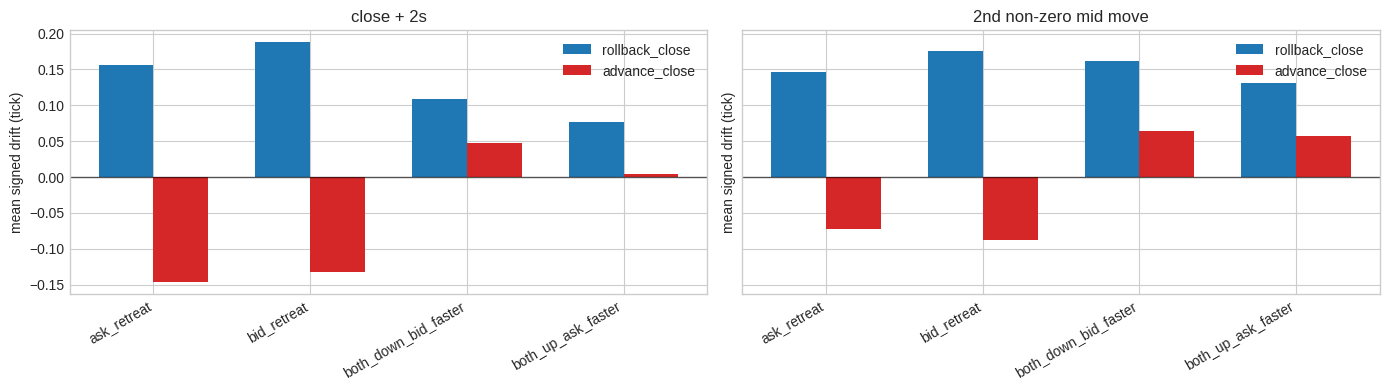

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, horizon_type, title in zip(
    axes,
    ['time_seconds', 'mid_moves'],
    ['close + 2s', '2nd non-zero mid move'],
):
    sub = mechanism_summary[mechanism_summary['horizon_type'] == horizon_type].copy()
    pivot = sub.pivot(index='entry_mechanism', columns='resolution_path', values='mean_signed_drift_tick')
    pivot = pivot.sort_index()
    x = np.arange(len(pivot.index))
    width = 0.35
    ax.bar(x - width / 2, pivot['rollback_close'], width=width, label='rollback_close', color='#1f77b4')
    ax.bar(x + width / 2, pivot['advance_close'], width=width, label='advance_close', color='#d62728')
    ax.axhline(0.0, color='black', linewidth=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=30, ha='right')
    ax.set_title(title)
    ax.set_ylabel('mean signed drift (tick)')
    ax.legend()
plt.tight_layout()


## 8. 小结

这份扩展展示支持同一个判断：

- `rollback_close` 之后，后续独立价格动作更偏 continuation，而且这个优势能延续到更长 horizon
- `advance_close` 之后，最短 horizon 上更偏回吐，拉长后会逐渐回到接近中性，但整体仍弱于 `rollback_close`
- 这个差异不只是“下一次 move 的方向”现象，而是能在短窗 drift、长窗 drift、move-aligned drift、以及 `close` 前后事件路径里同时看到

如果还要继续往下拆，下一步最自然的是：

- 按 `entry_mechanism` 单独画长事件图
- 再加上 `entry imbalance / active_turnover / duration_seconds` 分桶
- 或者继续把 horizon 拉到 `120s` 看 edge 衰减
